In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import os
import sys
from platform import python_version

In [3]:
print(sys.executable)
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

C:\Users\meman\AppData\Local\Programs\Python\Python312\python.exe


In [4]:
print(python_version())

3.12.2


In [5]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [6]:
class_names = dataset.class_names
print(class_names)
print(f"Total batches in dataset: {len(dataset)}")

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Total batches in dataset: 68


In [7]:
for image_batch, labels_batch in dataset.take(1):
    print(f"Shape of image batch: {image_batch.shape}")  # This will be (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
    print(f"Shape of labels batch: {labels_batch.numpy()}")

Shape of image batch: (32, 256, 256, 3)
Shape of labels batch: [1 0 0 1 1 1 1 1 0 0 0 1 1 1 0 0 2 0 0 1 1 0 1 0 1 0 1 0 0 1 0 0]


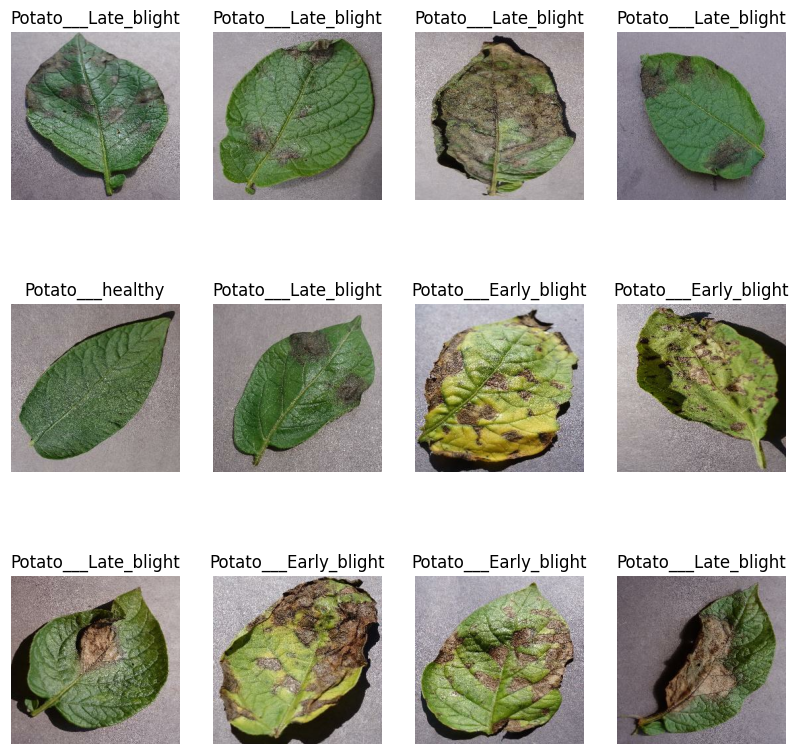

In [8]:
# Display a few images from the first batch
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(min(12, BATCH_SIZE)): # Ensure we don't go out of bounds if BATCH_SIZE < 12
        ax = plt.subplot(3, 4, i + 1)
        # image_batch[i] is already a single image, so .numpy().astype("uint8") is correct here
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")
plt.show() # Display the plot

In [9]:
# Function to partition the dataset
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12) # Use the dataset object directly

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size) # Skip both train and val sizes

    return train_ds, val_ds, test_ds

In [10]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset, shuffle=True)

print(f"Number of batches in train_ds: {len(train_ds)}")
print(f"Number of batches in val_ds: {len(val_ds)}")
print(f"Number of batches in test_ds: {len(test_ds)}")

Number of batches in train_ds: 54
Number of batches in val_ds: 6
Number of batches in test_ds: 8


In [14]:
# Define output directories for human-readable images
output_base_dir = './saved_datasets' # Use a distinct base directory
os.makedirs(output_base_dir, exist_ok=True) # Ensure the base directory exists

In [15]:
# Re-defining paths relative to the new base output directory for clarity
train_output_path = os.path.join(output_base_dir, 'train_dataset_images') # Note: using _images suffix here for clarity
val_output_path = os.path.join(output_base_dir, 'val_dataset_images')
test_output_path = os.path.join(output_base_dir, 'test_dataset_images')

In [16]:
def save_dataset_as_images(dataset, dataset_name, output_dir):
    """
    Saves images from a tf.data.Dataset to a specified directory.
    This function expects an UNBATCHED dataset for direct image saving.
    If your dataset is batched, use dataset.unbatch() before passing it here.

    Args:
        dataset: The tf.data.Dataset to process (expected to be unbatched).
        dataset_name: A string name for the dataset (e.g., 'train', 'validation').
        output_dir: The base directory where the images will be saved.
    """
    # Ensure the dataset_output_path is unique for each type (train, val, test)
    # The output_dir passed here is already specific, so just make sure it exists
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving {dataset_name} images to: {output_dir}")

    label_dirs = {}
    image_count = 0 # To keep track of total images saved

    # Iterate through the (unbatched) dataset
    for i, (image_tensor, label_tensor) in enumerate(dataset):
        # image_tensor here should be [Height, Width, Channels]

        # Ensure image is in uint8 format (0-255) for JPEG/PNG encoding
        if image_tensor.dtype != tf.uint8:
            # If your images are normalized (e.g., 0-1 float), scale them back to 0-255
            # tf.keras.preprocessing.image_dataset_from_directory typically returns float32 in [0, 255]
            # but it's good practice to ensure it's uint8
            if tf.reduce_max(image_tensor) <= 1.0: # Check if normalized to 0-1
                image_tensor = tf.cast(image_tensor * 255.0, tf.uint8)
            else: # Assume it's already 0-255 float, just cast
                image_tensor = tf.cast(image_tensor, tf.uint8)


        # Handle labels, ensuring they are simple integers
        # label_tensor can sometimes be a single-element tensor like tf.Tensor(5, shape=(), dtype=int32)
        # .numpy() extracts the scalar value.
        label_value = int(label_tensor.numpy()) # Explicitly cast to int
        label_str = str(label_value)

        # Create a subdirectory for the label if it doesn't exist
        if label_str not in label_dirs:
            label_dir_path = os.path.join(output_dir, label_str)
            os.makedirs(label_dir_path, exist_ok=True)
            label_dirs[label_str] = label_dir_path

        # Define the filename for the image
        # Using image_count to ensure unique names across entire saving process
        filename = os.path.join(label_dirs[label_str], f"image_{image_count:07d}_label_{label_str}.jpg")

        # Encode the image tensor to JPEG format
        encoded_image = tf.image.encode_jpeg(image_tensor, quality=95)

        # Write the encoded image bytes to the file
        tf.io.write_file(filename, encoded_image)

        image_count += 1
        if image_count % 100 == 0:
            print(f"  Processed {image_count} images in {dataset_name} dataset...")

    print(f"Finished saving {image_count} images for {dataset_name} dataset.")


In [17]:
print("\n--- Starting to save datasets as human-readable images ---")

print("\nSaving train_ds_images...")
save_dataset_as_images(train_ds.unbatch(), 'train_dataset_images', train_output_path)

print("\nSaving val_ds_images...")
save_dataset_as_images(val_ds.unbatch(), 'val_dataset_images', val_output_path)

print("\nSaving test_ds_images...")
save_dataset_as_images(test_ds.unbatch(), 'test_dataset_images', test_output_path)

print("\nAll datasets saved as human-readable images successfully!")
print(f"Check the '{output_base_dir}' directory for your image files.")


--- Starting to save datasets as human-readable images ---

Saving train_ds_images...
Saving train_dataset_images images to: ./saved_datasets\train_dataset_images
  Processed 100 images in train_dataset_images dataset...
  Processed 200 images in train_dataset_images dataset...
  Processed 300 images in train_dataset_images dataset...
  Processed 400 images in train_dataset_images dataset...
  Processed 500 images in train_dataset_images dataset...
  Processed 600 images in train_dataset_images dataset...
  Processed 700 images in train_dataset_images dataset...
  Processed 800 images in train_dataset_images dataset...
  Processed 900 images in train_dataset_images dataset...
  Processed 1000 images in train_dataset_images dataset...
  Processed 1100 images in train_dataset_images dataset...
  Processed 1200 images in train_dataset_images dataset...
  Processed 1300 images in train_dataset_images dataset...
  Processed 1400 images in train_dataset_images dataset...
  Processed 1500 im